In [1]:
using LinearAlgebra
using Plots

gr()

Plots.GRBackend()

In [2]:
function f_rosenbrock(x)
    return (1.0 - x[1])^2 + 100.0 * (x[2] - x[1]^2)^2
end

function f_rastrigin(x; A=10.0)
    return A * 2.0 + (x[1]^2 - A * cos(2.0 * pi * x[1])) + (x[2]^2 - A * cos(2.0 * pi * x[2]))
end

function f_schwefel(x)
    c = 418.9829
    return 2.0 * c - (x[1] * sin(sqrt(abs(x[1]))) + x[2] * sin(sqrt(abs(x[2]))))
end

function f_quad(x, a, b)
    return a * x[1]^2 + b * x[2]^2
end

function grad_quad(x, a, b)
    return [2.0 * a * x[1], 2.0 * b * x[2]]
end

grad_quad (generic function with 1 method)

In [3]:
function powell_1d(f, x0, Δx=0.1; ε=1e-12, max_iter=100)
    x₀ = x0
    x₁ = x₀ + Δx
    
    y₀ = f(x₀)
    y₁ = f(x₁)
    
    x_min = y₀ < y₁ ? x₀ : x₁
    
    iter_count = 0
    
    while iter_count < max_iter
        iter_count += 1
        
        if y₀ > y₁
            x₂ = x₀ + 2*Δx
        else
            x₂ = x₀ - Δx
        end
        y₂ = f(x₂)

        x_star = (x₀ + x₁ + x₂) / 3.0
        
        denom1 = x₁ - x₀
        denom2 = x₂ - x₀
        denom3 = x₁ - x₂
        
        if abs(denom1) < 1e-14 || abs(denom2) < 1e-14 || abs(denom3) < 1e-14
            x_star = (x₀ + x₁ + x₂) / 3.0
        else
            a = ((y₁ - y₀)/denom1 - (y₂ - y₀)/denom2) / denom3
            if abs(a) < 1e-14
                x_star = (x₀ + x₁ + x₂) / 3.0
            else
                b = (y₁ - y₀)/denom1 - a*(x₁ + x₀)
                x_star_calc = -b / (2*a)
                if isfinite(x_star_calc)
                    x_star = x_star_calc
                end
            end
        end
        
        y_min = min(y₀, y₁, y₂)
        if y_min == y₀
            x_min = x₀
        elseif y_min == y₁
            x_min = x₁
        else
            x_min = x₂
        end
        
        y_star = f(x_star)
        if y_star < y_min
            x_min = x_star
            y_min = y_star
        end
        
        if abs(x_min - x_star) ≤ ε
            break
        end
        
        best_x = x_min
        best_y = y_min
        if y_star < y_min
            best_x = x_star
            best_y = y_star
        end
        
        all_points = [(x=x₀, y=y₀), (x=x₁, y=y₁), (x=x₂, y=y₂), (x=x_star, y=y_star)]
        unique_points = []
        seen_x = Float64[]
        for p in all_points
            is_duplicate = false
            for x_seen in seen_x
                if abs(x_seen - p.x) < 1e-10
                    is_duplicate = true
                    break
                end
            end
            if !is_duplicate
                push!(unique_points, p)
                push!(seen_x, p.x)
            end
        end
        sort!(unique_points, by=p -> p.x)
        
        best_idx = findfirst(p -> abs(p.x - best_x) < 1e-10, unique_points)
        if best_idx === nothing
            best_idx = 1
        end
        
        if best_idx == 1
            x₁ = unique_points[1].x
            x₀ = x₁ - Δx
            x₂ = length(unique_points) > 1 ? unique_points[2].x : x₁ + Δx
        elseif best_idx == length(unique_points)
            x₁ = unique_points[end].x
            x₀ = length(unique_points) > 1 ? unique_points[end-1].x : x₁ - Δx
            x₂ = x₁ + Δx
        else
            x₀ = unique_points[best_idx-1].x
            x₁ = unique_points[best_idx].x
            x₂ = unique_points[best_idx+1].x
        end
        
        y₀ = f(x₀)
        y₁ = f(x₁)
        y₂ = f(x₂)
        
        Δx = max(abs(x₁ - x₀), abs(x₂ - x₁)) * 0.5
    end
    
    return x_min
end

function powell_multidimensional(f, x0; max_iter=200, eps=1e-8, verbose=true)
    x = copy(x0)
    history = [copy(x)]
    n = length(x)
    
    D = [zeros(n) for _ in 1:n]
    for i in 1:n
        D[i][i] = 1.0
    end
    # Снимки направлений для визуализации (аналог dir_snapshots из lab8.jl)
    dir_history = [deepcopy(D)]
    
    iter = 0
    for iter in 1:max_iter
        P = copy(x)
        
        for i in 1:n
            d = D[i]
            inner_f(alpha) = f(P + alpha * d)
            
            best_alpha = powell_1d(inner_f, 0.0)
            
            P = P + best_alpha * d
            push!(history, copy(P))
            push!(dir_history, deepcopy(D))
        end
        
        d_new = P - x
        
        if norm(d_new) < eps
            if verbose
                println("Сходимость достигнута на итерации $(iter)")
            end
            break
        end
        
        inner_f_new(alpha) = f(P + alpha * d_new)
        best_alpha_new = powell_1d(inner_f_new, 0.0)
        
        x_new = P + best_alpha_new * d_new
        push!(history, copy(x_new))
        push!(dir_history, deepcopy(D))
        
        for i in 1:(n-1)
            D[i] = D[i+1]
        end
        D[n] = d_new / norm(d_new)
        
        D_matrix = hcat(D...)
        if abs(det(D_matrix)) < 1e-3
            for i in 1:n
                D[i] = zeros(n)
                D[i][i] = 1.0
            end
        end
        
        x = x_new
    end
    
    if verbose && iter >= max_iter
        println("Достигнут лимит итераций $(max_iter)")
    end
    
    return x, history, dir_history
end

powell_multidimensional (generic function with 1 method)

In [4]:
function draw_arrow!(plt, ox, oy, dx, dy; color=:blue, lw=1.8)
    tx, ty = ox + dx, oy + dy
    plot!(plt, [ox, tx], [oy, ty], color=color, linewidth=lw, label="")
    head = 0.25
    perp_x, perp_y = -dy, dx
    plot!(plt, [tx, tx - head * dx + 0.3 * head * perp_x],
               [ty, ty - head * dy + 0.3 * head * perp_y],
          color=color, linewidth=lw, label="")
    plot!(plt, [tx, tx - head * dx - 0.3 * head * perp_x],
               [ty, ty - head * dy - 0.3 * head * perp_y],
          color=color, linewidth=lw, label="")
end

function plot_2d_contour(f, hist, dirs_hist, title_text;
                         xlims=(-5.0, 5.0),
                         ylims=(-5.0, 5.0),
                         levels=40,
                         grid_n=200,
                         auto_zoom=true,
                         zoom_pad=0.12,
                         min_span=0.6,
                         marker_size_iter=5,
                         marker_size_key=10)
    xs = [h[1] for h in hist]
    ys = [h[2] for h in hist]
    
    if auto_zoom && length(xs) > 0
        xmin, xmax = minimum(xs), maximum(xs)
        ymin, ymax = minimum(ys), maximum(ys)
        xspan = max(xmax - xmin, min_span)
        yspan = max(ymax - ymin, min_span)
        xpad = zoom_pad * xspan
        ypad = zoom_pad * yspan
        xlims = (xmin - xpad, xmax + xpad)
        ylims = (ymin - ypad, ymax + ypad)
    end
    
    xg = range(xlims[1], xlims[2], length=grid_n)
    yg = range(ylims[1], ylims[2], length=grid_n)
    Z = [f([x, y]) for y in yg, x in xg]
    
    p = contour(xg, yg, Z,
                levels=levels,
                linewidth=0.8,
                c=:plasma,
                xlabel="x₁",
                ylabel="x₂",
                title=title_text,
                colorbar=true,
                legend=:outertopright)
    
    plot!(p, xs, ys,
          linewidth=2.5,
          color=:red,
          label="Траектория",
          alpha=0.9)

    # Стрелки направлений Пауэлла из dirs_hist (как в lab8.jl)
    if dirs_hist !== nothing && length(dirs_hist) == length(hist)
        arrow_len = 0.06 * max(xlims[2] - xlims[1], ylims[2] - ylims[1])
        for k in eachindex(dirs_hist)
            ox, oy = hist[k]
            for d in dirs_hist[k]
                n = norm(d)
                if n < 1e-12
                    continue
                end
                ud = d / n * arrow_len
                draw_arrow!(p, ox, oy, ud[1], ud[2]; color=:blue, lw=1.8)
            end
        end
    end
    
    scatter!(p, xs, ys,
             markersize=marker_size_iter,
             color=:red,
             markerstrokewidth=1.5,
             markerstrokecolor=:black,
             label="Итерации",
             alpha=0.8)
    
    scatter!(p, [xs[1]], [ys[1]],
             markersize=marker_size_key,
             color=:yellow,
             marker=:star5,
             markerstrokewidth=2,
             markerstrokecolor=:black,
             label="Старт",
             alpha=1.0)
    
    scatter!(p, [xs[end]], [ys[end]],
             markersize=marker_size_key,
             color=:purple,
             marker=:diamond,
             markerstrokewidth=2,
             markerstrokecolor=:black,
             label="Минимум",
             alpha=1.0)
    
    return p
end

plot_2d_contour (generic function with 1 method)

In [5]:
function plot_3d_surface(f, hist, title_text;
                        xlims=(-5.0, 5.0),
                        ylims=(-5.0, 5.0),
                        grid_n=100,
                        auto_zoom=true,
                        zoom_pad=0.12,
                        min_span=0.6,
                        marker_size_iter=6,
                        marker_size_key=12)
    xs = [h[1] for h in hist]
    ys = [h[2] for h in hist]
    zs = [f(h) for h in hist]
    
    if auto_zoom && length(xs) > 0
        xmin, xmax = minimum(xs), maximum(xs)
        ymin, ymax = minimum(ys), maximum(ys)
        xspan = max(xmax - xmin, min_span)
        yspan = max(ymax - ymin, min_span)
        xpad = zoom_pad * xspan
        ypad = zoom_pad * yspan
        xlims = (xmin - xpad, xmax + xpad)
        ylims = (ymin - ypad, ymax + ypad)
    end
    
    xg = range(xlims[1], xlims[2], length=grid_n)
    yg = range(ylims[1], ylims[2], length=grid_n)
    Z = [f([x, y]) for y in yg, x in xg]
    
    p = surface(xg, yg, Z,
                color=:plasma,
                alpha=0.7,
                xlabel="x₁",
                ylabel="x₂",
                zlabel="f(x₁, x₂)",
                title=title_text,
                colorbar=true,
                legend=:outertopright)
    
    plot!(p, xs, ys, zs,
          linewidth=3,
          color=:red,
          label="Траектория",
          alpha=1.0)
    
    scatter!(p, xs, ys, zs,
             markersize=marker_size_iter,
             color=:red,
             markerstrokewidth=1.5,
             markerstrokecolor=:black,
             label="Итерации",
             alpha=0.9)
    
    scatter!(p, [xs[1]], [ys[1]], [zs[1]],
             markersize=marker_size_key,
             color=:yellow,
             marker=:star5,
             markerstrokewidth=2.5,
             markerstrokecolor=:black,
             label="Старт",
             alpha=1.0)
    
    scatter!(p, [xs[end]], [ys[end]], [zs[end]],
             markersize=marker_size_key,
             color=:purple,
             marker=:diamond,
             markerstrokewidth=2.5,
             markerstrokecolor=:black,
             label="Минимум",
             alpha=1.0)
    
    return p
end

plot_3d_surface (generic function with 1 method)

Тест 1: Функция Розенброка
Сходимость достигнута на итерации 12
Начальная точка: x₀ = [-1.2, 1.0]
Найденный минимум: x* = [-0.11371038270539331, -0.016715395017014918]
Значение функции: f(x*) = 1.328236064301037
Точное значение: x* = [1.0, 1.0]
Ошибка: ||x* - [1,1]|| = 1.5079990089553768
Число точек в истории: 36



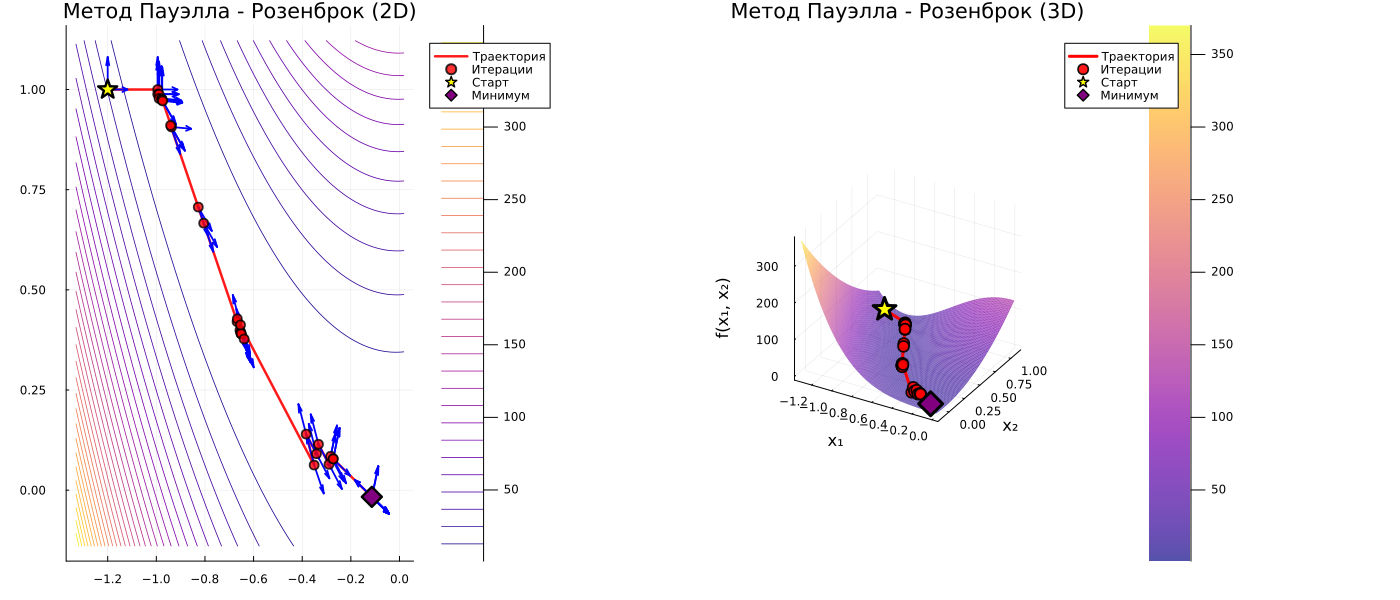

In [6]:
println("=" ^ 60)
println("Тест 1: Функция Розенброка")
println("=" ^ 60)
x0_rosen = [-1.2, 1.0]
x_rosen, hist_rosen, dirs_rosen = powell_multidimensional(f_rosenbrock, x0_rosen; max_iter=200, eps=1e-4, verbose=true)
println("Начальная точка: x₀ = $(x0_rosen)")
println("Найденный минимум: x* = $(x_rosen)")
println("Значение функции: f(x*) = $(f_rosenbrock(x_rosen))")
println("Точное значение: x* = [1.0, 1.0]")
println("Ошибка: ||x* - [1,1]|| = $(norm(x_rosen - [1.0, 1.0]))")
println("Число точек в истории: $(length(hist_rosen))")
println()


p_rosen_2d = plot_2d_contour(f_rosenbrock, hist_rosen, dirs_rosen, "Метод Пауэлла - Розенброк (2D)";
                            xlims=(-2.0, 2.0), ylims=(-1.0, 2.0), levels=30, auto_zoom=true)
p_rosen_3d = plot_3d_surface(f_rosenbrock, hist_rosen, "Метод Пауэлла - Розенброк (3D)";
                            xlims=(-2.0, 2.0), ylims=(-1.0, 2.0), auto_zoom=true)

plot(p_rosen_2d, p_rosen_3d, layout=(1, 2), size=(1400, 600))

Тест 2: Функция Растригина
Сходимость достигнута на итерации 2
Начальная точка: x₀ = [0.8, 0.8]
Найденный минимум: x* = [0.9949460516502808, 0.9949460516502808]
Значение функции: f(x*) = 1.9899181770087289
Точное значение: x* = [0.0, 0.0]
Ошибка: ||x* - [0,0]|| = 1.4070662000733891
Число точек в истории: 6



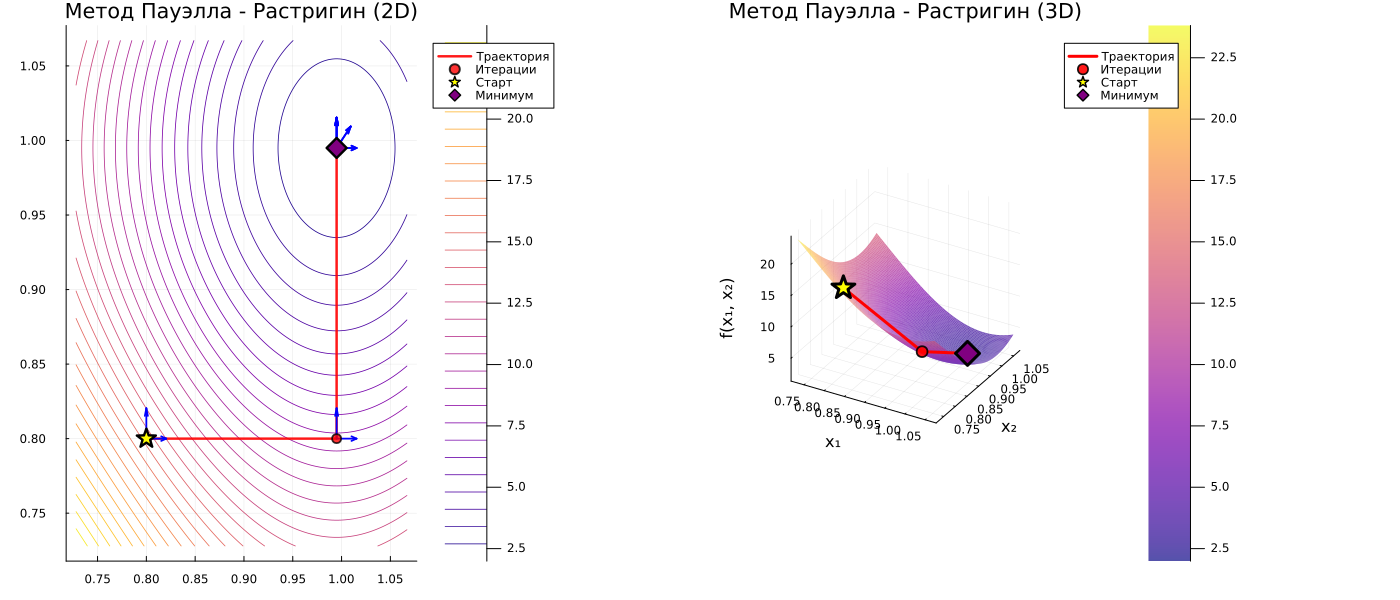

In [7]:
println("=" ^ 60)
println("Тест 2: Функция Растригина")
println("=" ^ 60)
x0_ras = [0.8, 0.8]
x_ras, hist_ras, dirs_ras = powell_multidimensional(f_rastrigin, x0_ras; max_iter=200, eps=1e-4, verbose=true)
println("Начальная точка: x₀ = $(x0_ras)")
println("Найденный минимум: x* = $(x_ras)")
println("Значение функции: f(x*) = $(f_rastrigin(x_ras))")
println("Точное значение: x* = [0.0, 0.0]")
println("Ошибка: ||x* - [0,0]|| = $(norm(x_ras))")
println("Число точек в истории: $(length(hist_ras))")
println()

p_ras_2d = plot_2d_contour(f_rastrigin, hist_ras, dirs_ras, "Метод Пауэлла - Растригин (2D)";
                         xlims=(-5.12, 5.12), ylims=(-5.12, 5.12), levels=30, auto_zoom=true)
p_ras_3d = plot_3d_surface(f_rastrigin, hist_ras, "Метод Пауэлла - Растригин (3D)";
                          xlims=(-5.12, 5.12), ylims=(-5.12, 5.12), auto_zoom=true)

plot(p_ras_2d, p_ras_3d, layout=(1, 2), size=(1400, 600))

Тест 3: Функция Швефеля
Сходимость достигнута на итерации 3
Начальная точка: x₀ = [400.0, 400.0]
Найденный минимум: x* = [420.96882869892926, 420.96871921130025]
Значение функции: f(x*) = 2.5456081061747682e-5
Число точек в истории: 9



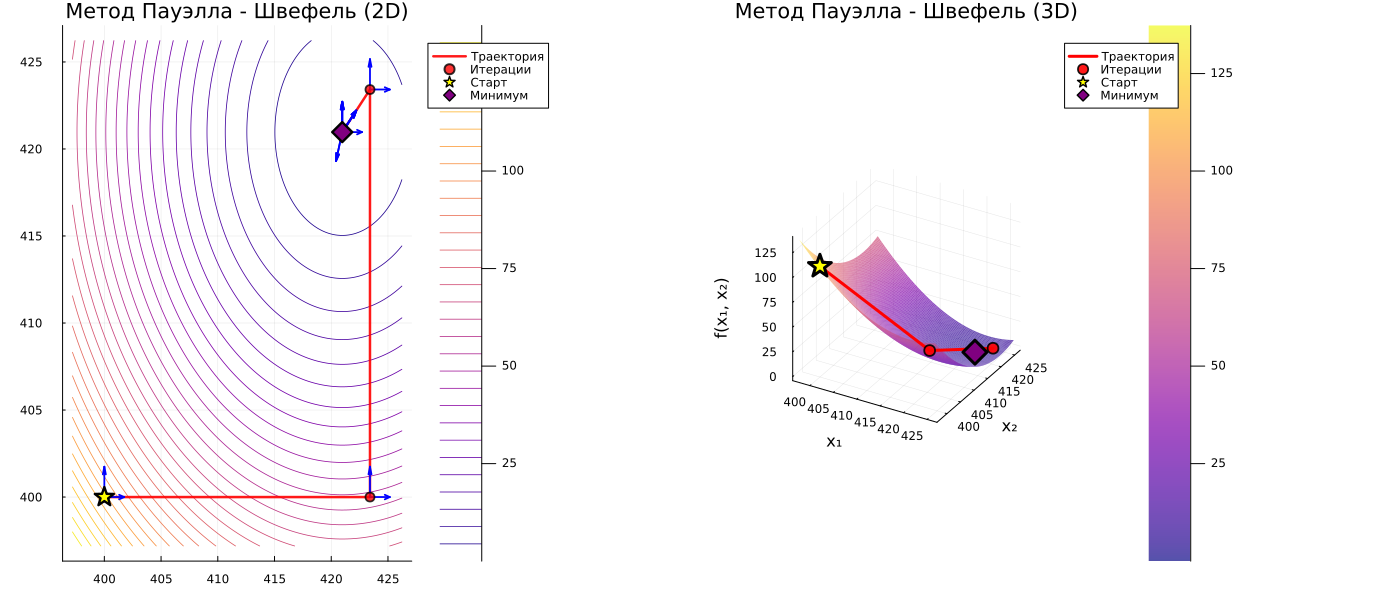

In [8]:
println("=" ^ 60)
println("Тест 3: Функция Швефеля")
println("=" ^ 60)
x0_sch = [400.0, 400.0]
x_sch, hist_sch, dirs_sch = powell_multidimensional(f_schwefel, x0_sch; max_iter=200, eps=1e-4, verbose=true)
println("Начальная точка: x₀ = $(x0_sch)")
println("Найденный минимум: x* = $(x_sch)")
println("Значение функции: f(x*) = $(f_schwefel(x_sch))")
println("Число точек в истории: $(length(hist_sch))")
println()

p_sch_2d = plot_2d_contour(f_schwefel, hist_sch, dirs_sch, "Метод Пауэлла - Швефель (2D)";
                         xlims=(50.0, 450.0), ylims=(50.0, 450.0), levels=30, auto_zoom=true)
p_sch_3d = plot_3d_surface(f_schwefel, hist_sch, "Метод Пауэлла - Швефель (3D)";
                          xlims=(50.0, 450.0), ylims=(50.0, 450.0), auto_zoom=true)

plot(p_sch_2d, p_sch_3d, layout=(1, 2), size=(1400, 600))

In [9]:
println("=" ^ 60)
println("Тест 4: Квадратичная функция")
println("=" ^ 60)

a_quad = 1.0
quad_cases = [1.0, 5.0, 10.0]
quad_runs = Vector{NamedTuple}(undef, length(quad_cases))

for (i, b_quad) in enumerate(quad_cases)
    fq(x) = f_quad(x, a_quad, b_quad)
    
    x0_quad = [4.0, -3.0]
    println("\n===== Quadratic a=$(a_quad), b=$(b_quad) =====")
    x_quad, hist_quad, dirs_quad = powell_multidimensional(fq, x0_quad; max_iter=400, eps=1e-12, verbose=true)
    println("Начальная точка: x₀ = $(x0_quad)")
    println("Найденный минимум: x* = $(x_quad)")
    println("Значение функции: f(x*) = $(fq(x_quad))")
    println("Число точек в истории: $(length(hist_quad))")
    
    quad_runs[i] = (b=b_quad, hist=hist_quad)
end

Тест 4: Квадратичная функция

===== Quadratic a=1.0, b=1.0 =====
Сходимость достигнута на итерации 2
Начальная точка: x₀ = [4.0, -3.0]
Найденный минимум: x* = [6.394884621840152e-14, 8.526512829121286e-14]
Значение функции: f(x*) = 1.1359597035181754e-26
Число точек в истории: 6

===== Quadratic a=1.0, b=5.0 =====
Сходимость достигнута на итерации 2
Начальная точка: x₀ = [4.0, -3.0]
Найденный минимум: x* = [4.2021031463190633e-13, 1.1205608390185202e-13]
Значение функции: f(x*) = 2.393595382201402e-25
Число точек в истории: 6

===== Quadratic a=1.0, b=10.0 =====
Сходимость достигнута на итерации 2
Начальная точка: x₀ = [4.0, -3.0]
Найденный минимум: x* = [-7.380259925206193e-13, -9.840346566941454e-14]
Значение функции: f(x*) = 6.415147861935617e-25
Число точек в истории: 6


In [10]:
p_quad1_2d = plot_2d_contour(x -> f_quad(x, a_quad, 1.0), quad_runs[1].hist, dirs_quad, 
                             "Метод Пауэлла - Квадратичная a=1, b=1 (2D)";
                             xlims=(-5.0, 5.0), ylims=(-5.0, 5.0), levels=20, auto_zoom=true)
p_quad1_3d = plot_3d_surface(x -> f_quad(x, a_quad, 1.0), quad_runs[1].hist, 
                             "Метод Пауэлла - Квадратичная a=1, b=1 (3D)";
                             xlims=(-5.0, 5.0), ylims=(-5.0, 5.0), auto_zoom=true)

p_quad5_2d = plot_2d_contour(x -> f_quad(x, a_quad, 5.0), quad_runs[2].hist, 
                             "Метод Пауэлла - Квадратичная a=1, b=5 (2D)";
                             xlims=(-5.0, 5.0), ylims=(-5.0, 5.0), levels=20, auto_zoom=true)
p_quad5_3d = plot_3d_surface(x -> f_quad(x, a_quad, 5.0), quad_runs[2].hist, 
                             "Метод Пауэлла - Квадратичная a=1, b=5 (3D)";
                             xlims=(-5.0, 5.0), ylims=(-5.0, 5.0), auto_zoom=true)

p_quad10_2d = plot_2d_contour(x -> f_quad(x, a_quad, 10.0), quad_runs[3].hist, 
                              "Метод Пауэлла - Квадратичная a=1, b=10 (2D)";
                              xlims=(-5.0, 5.0), ylims=(-5.0, 5.0), levels=20, auto_zoom=true)
p_quad10_3d = plot_3d_surface(x -> f_quad(x, a_quad, 10.0), quad_runs[3].hist, 
                              "Метод Пауэлла - Квадратичная a=1, b=10 (3D)";
                              xlims=(-5.0, 5.0), ylims=(-5.0, 5.0), auto_zoom=true)

plot(p_quad1_2d, p_quad1_3d, p_quad5_2d, p_quad5_3d, p_quad10_2d, p_quad10_3d, layout=(3, 2), size=(1800, 1200))

LoadError: UndefVarError: `dirs_quad` not defined in `Main`
Suggestion: check for spelling errors or missing imports.